In [1]:
import io, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, soundfile as sf
from datasets import load_dataset, Audio
from IPython.display import Audio as Player, display

LABEL_HOP = 512          # each reference label covers 512 samples = 32 ms at 16 kHz

c:\Users\Esma Nur Mantı\Desktop\vad-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("guynich/librispeech_asr_test_vad", split="test.clean", streaming=True)
dataset = dataset.cast_column("audio", Audio(decode=False))
sample = next(iter(dataset))

audio = sample["audio"]
source = io.BytesIO(audio["bytes"]) if audio["bytes"] is not None else audio["path"]
y, sr = sf.read(source)
if y.ndim > 1:
    y = y.mean(axis=1)

reference = np.asarray(sample["speech"], dtype=int)        # 1 = speech, 0 = non-speech
valid = np.asarray(sample["confidence"], dtype=int) == 1   # only confident labels are scored
n_blocks = len(y) // LABEL_HOP
assert len(reference) == n_blocks
t = np.arange(len(y)) / sr

print("File:", sample["file"], "| Duration:", round(len(y) / sr, 3), "s | Labels:", n_blocks)

File: 6930-75918-0000.flac | Duration: 3.505 s | Labels: 109


In [3]:
def block_rms(signal):
    """RMS energy of each 512-sample block (same grid as the reference labels)."""
    blocks = signal[:n_blocks * LABEL_HOP].reshape(n_blocks, LABEL_HOP)
    return np.sqrt(np.mean(blocks ** 2, axis=1))

def to_db(values):
    return 20 * np.log10(values + 1e-10)

def metrics(true, pred):
    tp = int(np.sum((true == 1) & (pred == 1))); tn = int(np.sum((true == 0) & (pred == 0)))
    fp = int(np.sum((true == 0) & (pred == 1))); fn = int(np.sum((true == 1) & (pred == 0)))
    miss = fn / (tp + fn) if tp + fn else np.nan          # share of speech that was cut
    fa = fp / (fp + tn) if fp + tn else np.nan            # share of non-speech called speech
    return {"miss_rate": miss, "false_alarm_rate": fa, "balanced_accuracy": 1 - (miss + fa) / 2}

true = reference[valid]

# Sample-level mask of the speech regions, built from the reference labels
speech_mask = np.zeros(len(y), dtype=bool)
speech_mask[:n_blocks * LABEL_HOP] = np.repeat(reference == 1, LABEL_HOP)

def make_noise(n, kind, rng):
    """white: flat spectrum | pink: more low-frequency power | fluctuating: pink noise whose level drifts over time."""
    white = rng.normal(size=n)
    if kind == "white":
        return white
    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n)
    freqs[0] = freqs[1]                       # avoid division by zero at 0 Hz
    pink = np.fft.irfft(spectrum / np.sqrt(freqs), n=n)
    if kind == "pink":
        return pink
    # Slowly varying gain: one random value every 200 ms, about 4 dB standard deviation
    control = rng.normal(size=int(n / sr * 5) + 2) * 4.0
    gain_db = np.interp(np.arange(n), np.linspace(0, n, len(control)), control)
    return pink * 10 ** (gain_db / 20)

def add_noise(signal, snr_db, kind="white", seed=0):
    """Add noise at the requested SNR; speech power is measured only where speech is present."""
    rng = np.random.default_rng(seed)
    noise = make_noise(len(signal), kind, rng)
    signal_power = np.mean(signal[speech_mask] ** 2)
    noise = noise * np.sqrt(signal_power / (np.mean(noise ** 2) * 10 ** (snr_db / 10)))
    return signal + noise

In [4]:
def floor_stats(rms_values):
    """Label-free estimates of the noise floor and of how much it fluctuates."""
    db = to_db(rms_values)
    p5, p10, p20 = np.percentile(db, [5, 10, 20])
    return p10, p20 - p5

rows = []
for kind in ["white", "fluctuating"]:
    for snr in [None, 20, 10, 0]:
        signal = y if snr is None else add_noise(y, snr, kind)
        db = to_db(block_rms(signal))
        floor, spread = floor_stats(block_rms(signal))
        silence = db[valid & (reference == 0)]
        rows.append({"noise": kind, "snr_db": "clean" if snr is None else snr,
                     "estimated floor (p10)": floor, "estimated spread (p20 - p5)": spread,
                     "true non-speech mean": silence.mean(), "true non-speech std": silence.std()})
display(pd.DataFrame(rows).round(2))

,noise,snr_db,estimated floor (p10),estimated spread (p20 - p5),true non-speech mean,true non-speech std
0,white,clean,-53.57,7.09,-51.14,4.63
1,white,20,-47.90,2.26,-46.67,1.85
2,white,10,-39.27,0.65,-39.00,0.40
3,white,0,-29.59,0.39,-29.38,0.24
4,fluctuating,clean,-53.57,7.09,-51.14,4.63
5,fluctuating,20,-47.96,4.95,-47.28,3.04
6,fluctuating,10,-39.97,4.01,-39.60,2.71
7,fluctuating,0,-31.61,5.17,-29.95,2.77


In [5]:
def th_fixed_margin(rms_values, margin_db=6):
    """EXP-02 method: noise floor plus a constant margin."""
    return 10 ** ((floor_stats(rms_values)[0] + margin_db) / 20)

def th_leading(rms_values, seconds=0.5, margin_db=6):
    """Assume the first 0.5 s is noise only and use its mean level as the floor."""
    n = int(seconds * sr / LABEL_HOP)
    return 10 ** ((to_db(rms_values[:n]).mean() + margin_db) / 20)

def th_spread_margin(rms_values, k=2.0, min_margin_db=1.0):
    """Margin scales with the measured fluctuation of the floor instead of being constant."""
    floor, spread = floor_stats(rms_values)
    return 10 ** ((floor + max(k * spread, min_margin_db)) / 20)

def th_otsu(rms_values):
    """Otsu's method: the split of the dB histogram that best separates two groups."""
    db = to_db(rms_values)
    candidates = np.linspace(db.min(), db.max(), 200)[1:-1]
    best_score, best_c = -1, candidates[0]
    for c in candidates:
        low, high = db[db <= c], db[db > c]
        if len(low) == 0 or len(high) == 0:
            continue
        score = len(low) * len(high) * (low.mean() - high.mean()) ** 2   # between-class variance
        if score > best_score:
            best_score, best_c = score, c
    return 10 ** (best_c / 20)

def th_oracle(rms_values):
    """Best possible single threshold, chosen with the labels (upper bound, not usable in practice)."""
    candidates = np.logspace(-3.5, -0.5, 120)
    scores = [metrics(true, (rms_values[valid] > th).astype(int))["balanced_accuracy"] for th in candidates]
    return candidates[int(np.argmax(scores))]

METHODS = {
    "fixed margin 6 dB": th_fixed_margin,
    "fixed margin 3 dB": lambda r: th_fixed_margin(r, 3),
    "leading 0.5 s + 6 dB": th_leading,
    "spread-based margin": th_spread_margin,
    "otsu": th_otsu,
    "oracle": th_oracle,
}

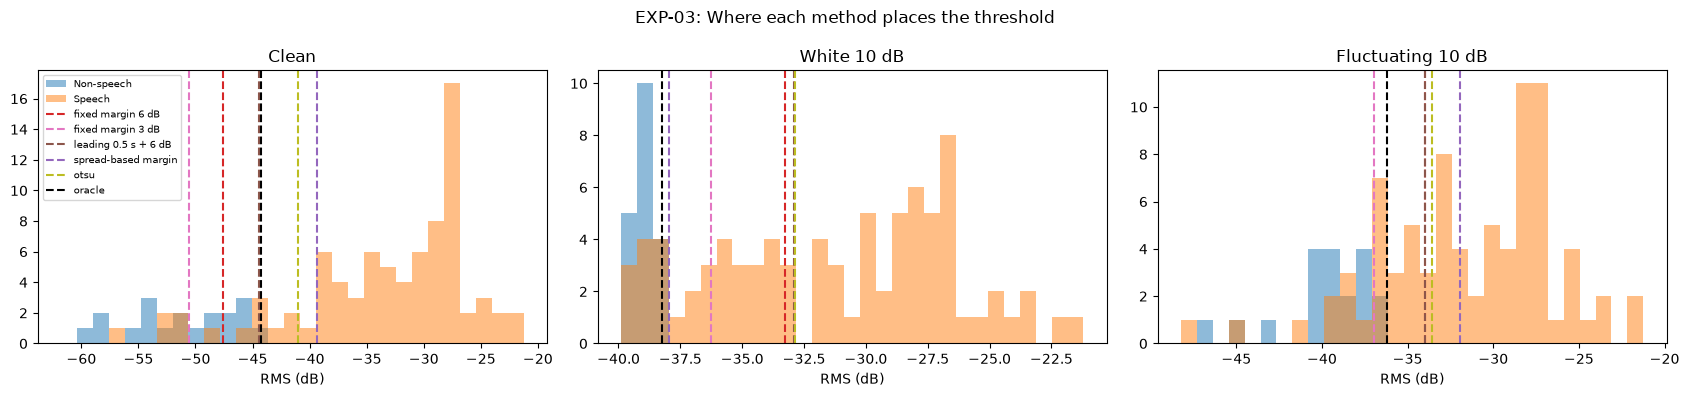

In [6]:
examples = {"Clean": y, "White 10 dB": add_noise(y, 10, "white"), "Fluctuating 10 dB": add_noise(y, 10, "fluctuating")}
colors = ["tab:red", "tab:pink", "tab:brown", "tab:purple", "tab:olive", "black"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (name, signal) in zip(axes, examples.items()):
    r = block_rms(signal); db = to_db(r)
    bins = np.linspace(db.min(), db.max(), 30)
    ax.hist(db[valid & (reference == 0)], bins=bins, alpha=0.5, label="Non-speech")
    ax.hist(db[valid & (reference == 1)], bins=bins, alpha=0.5, label="Speech")
    for (method, fn), color in zip(METHODS.items(), colors):
        ax.axvline(to_db(fn(r)), color=color, linestyle="--", label=method)
    ax.set_title(name); ax.set_xlabel("RMS (dB)")
axes[0].legend(fontsize=7)
plt.suptitle("EXP-03: Where each method places the threshold"); plt.tight_layout(); plt.show()

In [7]:
SNRS = [30, 20, 15, 10, 5, 0, -5]
KINDS = ["white", "pink", "fluctuating"]
N_SEEDS = 20

rows = []
for kind in KINDS:
    for snr in SNRS:
        for seed in range(N_SEEDS):
            r = block_rms(add_noise(y, snr, kind, seed))
            for method, fn in METHODS.items():
                th = fn(r)
                rows.append({"noise": kind, "snr_db": snr, "seed": seed, "method": method, "threshold_db": to_db(th),
                             **metrics(true, (r[valid] > th).astype(int))})
results = pd.DataFrame(rows)
print("Runs:", len(results))

Runs: 2520


In [8]:
for kind in KINDS:
    print(f"Balanced accuracy - {kind} noise")
    display(results[results["noise"] == kind].pivot_table(
        index="method", columns="snr_db", values="balanced_accuracy", aggfunc="mean").loc[list(METHODS), SNRS].round(3))

Balanced accuracy - white noise


snr_db,30,20,15,10,5,0,-5
method,,,,,,,
fixed margin 6 dB,0.841,0.938,0.900,0.807,0.705,0.531,0.500
fixed margin 3 dB,0.733,0.831,0.939,0.904,0.809,0.703,0.533
leading 0.5 s + 6 dB,0.939,0.922,0.876,0.799,0.698,0.530,0.500
spread-based margin,0.925,0.918,0.895,0.929,0.913,0.843,0.746
otsu,0.915,0.869,0.839,0.796,0.760,0.734,0.693
oracle,0.947,0.947,0.942,0.936,0.924,0.855,0.790


Balanced accuracy - pink noise


snr_db,30,20,15,10,5,0,-5
method,,,,,,,
fixed margin 6 dB,0.838,0.929,0.905,0.835,0.756,0.584,0.511
fixed margin 3 dB,0.740,0.803,0.848,0.829,0.762,0.686,0.570
leading 0.5 s + 6 dB,0.940,0.921,0.875,0.801,0.692,0.538,0.504
spread-based margin,0.920,0.927,0.904,0.846,0.761,0.684,0.590
otsu,0.916,0.868,0.841,0.802,0.761,0.679,0.573
oracle,0.946,0.943,0.928,0.877,0.806,0.713,0.631


Balanced accuracy - fluctuating noise


snr_db,30,20,15,10,5,0,-5
method,,,,,,,
fixed margin 6 dB,0.841,0.922,0.894,0.835,0.746,0.638,0.540
fixed margin 3 dB,0.737,0.811,0.842,0.801,0.741,0.647,0.542
leading 0.5 s + 6 dB,0.940,0.919,0.884,0.816,0.708,0.592,0.532
spread-based margin,0.916,0.915,0.871,0.814,0.729,0.632,0.544
otsu,0.915,0.867,0.841,0.794,0.751,0.665,0.544
oracle,0.947,0.943,0.921,0.870,0.790,0.702,0.622


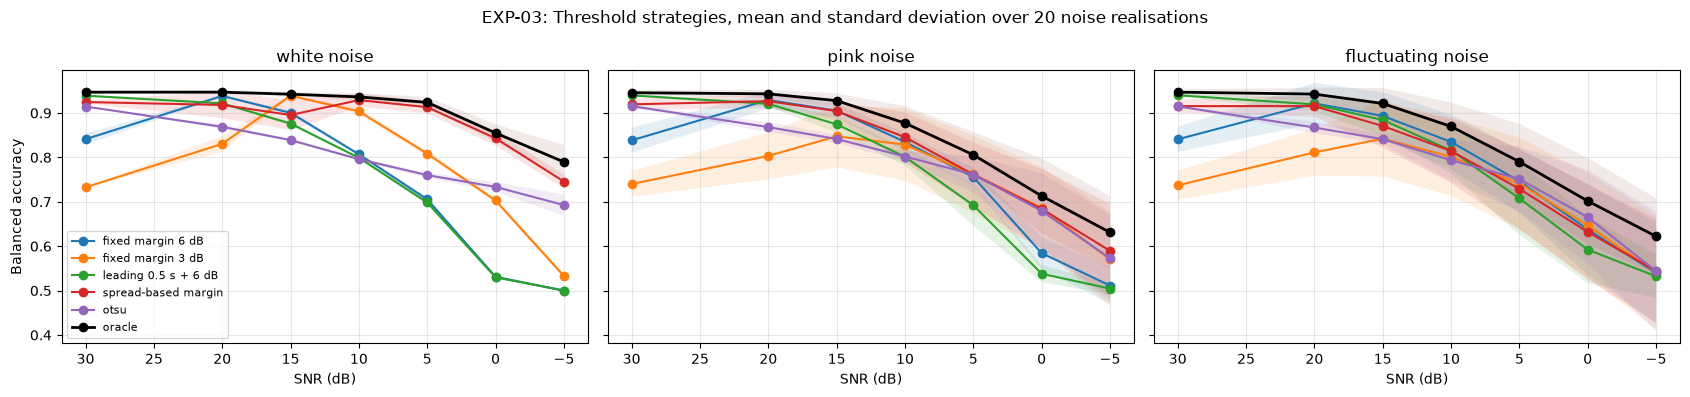

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, kind in zip(axes, KINDS):
    part = results[results["noise"] == kind]
    for method in METHODS:
        stats = part[part["method"] == method].groupby("snr_db")["balanced_accuracy"].agg(["mean", "std"]).loc[SNRS]
        style = {"color": "black", "linewidth": 2} if method == "oracle" else {}
        ax.plot(SNRS, stats["mean"], marker="o", label=method, **style)
        ax.fill_between(SNRS, stats["mean"] - stats["std"], stats["mean"] + stats["std"], alpha=0.12)
    ax.set_title(f"{kind} noise"); ax.set_xlabel("SNR (dB)"); ax.invert_xaxis(); ax.grid(alpha=0.3)
axes[0].set_ylabel("Balanced accuracy"); axes[0].legend(fontsize=8)
plt.suptitle("EXP-03: Threshold strategies, mean and standard deviation over 20 noise realisations")
plt.tight_layout(); plt.show()

In [10]:
detail = results[results["method"].isin(["fixed margin 6 dB", "spread-based margin", "otsu", "oracle"])]
for value in ["miss_rate", "false_alarm_rate"]:
    print(value)
    display(detail.pivot_table(index=["noise", "method"], columns="snr_db", values=value, aggfunc="mean")[SNRS].round(3))

miss_rate


snr_db                              30     20     15     10     5      0   \
noise       method                                                          
fluctuating fixed margin 6 dB    0.074  0.112  0.160  0.267  0.402  0.585   
            oracle               0.106  0.112  0.144  0.208  0.327  0.402   
            otsu                 0.170  0.265  0.315  0.381  0.382  0.377   
            spread-based margin  0.169  0.166  0.229  0.316  0.441  0.560   
pink        fixed margin 6 dB    0.073  0.120  0.174  0.312  0.470  0.795   
            oracle               0.109  0.111  0.139  0.209  0.312  0.358   
            otsu                 0.169  0.263  0.317  0.393  0.424  0.430   
            spread-based margin  0.161  0.141  0.160  0.206  0.282  0.332   
white       fixed margin 6 dB    0.073  0.123  0.199  0.386  0.589  0.938   
            oracle               0.106  0.106  0.115  0.127  0.147  0.259   
            otsu                 0.171  0.262  0.322  0.408  0.480  0.533   
            spread-based margin  0.151  0.093  0.085  0.113  0.166  0.309   

snr_db                             -5   
noise       method                      
fluctuating fixed margin 6 dB    0.726  
            oracle               0.437  
            otsu                 0.515  
            spread-based margin  0.640  
pink        fixed margin 6 dB    0.930  
            oracle               0.314  
            otsu                 0.536  
            spread-based margin  0.426  
white       fixed margin 6 dB    1.000  
            oracle               0.315  
            otsu                 0.615  
            spread-based margin  0.506

false_alarm_rate


snr_db                              30     20     15     10     5      0   \
noise       method                                                          
fluctuating fixed margin 6 dB    0.245  0.045  0.053  0.063  0.105  0.139   
            oracle               0.000  0.003  0.013  0.053  0.092  0.195   
            otsu                 0.000  0.000  0.003  0.032  0.116  0.292   
            spread-based margin  0.000  0.003  0.029  0.055  0.100  0.176   
pink        fixed margin 6 dB    0.250  0.021  0.016  0.018  0.018  0.037   
            oracle               0.000  0.003  0.005  0.037  0.076  0.216   
            otsu                 0.000  0.000  0.000  0.003  0.053  0.211   
            spread-based margin  0.000  0.005  0.032  0.103  0.195  0.300   
white       fixed margin 6 dB    0.245  0.000  0.000  0.000  0.000  0.000   
            oracle               0.000  0.000  0.000  0.000  0.005  0.032   
            otsu                 0.000  0.000  0.000  0.000  0.000  0.000   
            spread-based margin  0.000  0.071  0.124  0.029  0.008  0.005   

snr_db                             -5   
noise       method                      
fluctuating fixed margin 6 dB    0.195  
            oracle               0.318  
            otsu                 0.397  
            spread-based margin  0.271  
pink        fixed margin 6 dB    0.047  
            oracle               0.424  
            otsu                 0.318  
            spread-based margin  0.395  
white       fixed margin 6 dB    0.000  
            oracle               0.105  
            otsu                 0.000  
            spread-based margin  0.003

In [11]:
mean_acc = results.pivot_table(index="method", columns="noise", values="balanced_accuracy",
                               aggfunc="mean").loc[list(METHODS), KINDS]
gap = mean_acc.loc["oracle"] - mean_acc
summary = pd.concat({"mean balanced accuracy": mean_acc, "gap to oracle": gap}, axis=1).round(3)
display(summary)

mean balanced accuracy                    gap to oracle  \
noise                                 white   pink fluctuating         white   
method                                                                         
fixed margin 6 dB                     0.746  0.766       0.774         0.160   
fixed margin 3 dB                     0.779  0.748       0.732         0.127   
leading 0.5 s + 6 dB                  0.752  0.753       0.770         0.154   
spread-based margin                   0.881  0.804       0.775         0.025   
otsu                                  0.801  0.777       0.768         0.105   
oracle                                0.906  0.835       0.828         0.000   

                                         
noise                  pink fluctuating  
method                                   
fixed margin 6 dB     0.069       0.054  
fixed margin 3 dB     0.087       0.096  
leading 0.5 s + 6 dB  0.082       0.058  
spread-based margin   0.030       0.053  
otsu                  0.058       0.060  
oracle                0.000       0.000

In [12]:
rows = []
for k in [1.0, 1.5, 2.0, 3.0, 4.0]:
    for kind in KINDS:
        for snr in SNRS:
            for seed in range(N_SEEDS):
                r = block_rms(add_noise(y, snr, kind, seed))
                th = th_spread_margin(r, k)
                rows.append({"k": k, "noise": kind, **metrics(true, (r[valid] > th).astype(int))})
display(pd.DataFrame(rows).pivot_table(index="k", columns="noise",
        values=["balanced_accuracy", "miss_rate", "false_alarm_rate"], aggfunc="mean").round(3))

balanced_accuracy               false_alarm_rate                \
noise       fluctuating   pink  white      fluctuating   pink  white   
k                                                                      
1.0               0.759  0.754  0.833            0.311  0.359  0.149   
1.5               0.787  0.797  0.868            0.161  0.221  0.072   
2.0               0.775  0.804  0.881            0.091  0.147  0.034   
3.0               0.702  0.769  0.873            0.029  0.072  0.002   
4.0               0.617  0.704  0.839            0.011  0.033  0.000   

        miss_rate                
noise fluctuating   pink  white  
k                                
1.0         0.171  0.132  0.185  
1.5         0.265  0.185  0.192  
2.0         0.360  0.244  0.203  
3.0         0.566  0.390  0.253  
4.0         0.754  0.559  0.323

In [13]:
os.makedirs("../results", exist_ok=True)
results.groupby(["noise", "method", "snr_db"])[["miss_rate", "false_alarm_rate", "balanced_accuracy"]].agg(
    ["mean", "std"]).to_csv("../results/exp03_adaptive_threshold.csv")
summary.to_csv("../results/exp03_summary.csv")
print("Saved.")

Saved.
